# What is Classification?

While **regression** predicts a continuous number, **classification** predicts a **category/class**. The output is **discrete**, not a range of values.

### Examples

* **Email →** Spam or Not Spam *(binary classification)*
* **Tumor scan →** Benign or Malignant *(binary classification)*
* **Handwritten digit →** 0–9 *(multi-class classification)*
* **Customer →** Will churn / Won't churn *(binary classification)*

### Regression vs Classification

| Problem Type       | Question                             | Output        |
| ------------------ | ------------------------------------ | ------------- |
| **Regression**     | How much will this house sell for?   | Rs. 4,500,000 |
| **Classification** | Will this house sell within 30 days? | Yes / No      |

# Types of Classification Problems

| Type                           | Description                                                               | Example                                          |
| ------------------------------ | ------------------------------------------------------------------------- | ------------------------------------------------ |
| **Binary Classification**      | Exactly **2 classes**                                                     | Spam vs Not Spam                                 |
| **Multi-class Classification** | **3 or more classes**, where each sample belongs to exactly **one class** | Digit recognition (0–9)                          |
| **Multi-label Classification** | Each sample can belong to **multiple classes at the same time**           | A movie tagged as both "Action" **AND** "Comedy" |


# What is Logistic Regression?

**Logistic Regression** is a supervised machine learning algorithm mainly used for **classification problems**. It predicts the **probability** of a data point belonging to a particular class and then assigns it to a class based on a threshold.

For example:

* Email → Spam or Not Spam
* Student → Pass or Fail
* Customer → Will churn or Won't churn
* Tumor → Benign or Malignant

## How Does Logistic Regression Work?

Logistic Regression uses the **sigmoid function** to convert its output into a probability between **0 and 1**.

[
\sigma(z) = \frac{1}{1 + e^{-z}}
]

A common threshold is **0.5**:

```text
Probability ≥ 0.5 → Class 1
Probability < 0.5 → Class 0
```

For example:

```text
0.80 → Class 1
0.25 → Class 0
```

## Example

Suppose we predict whether a student will pass based on study hours:

| Study Hours | Probability | Prediction |
| ----------: | ----------: | ---------- |
|           2 |        0.20 | Fail       |
|           5 |        0.65 | Pass       |
|           8 |        0.90 | Pass       |

## Key Points

* Used mainly for **classification**.
* Outputs a **probability between 0 and 1**.
* Uses the **sigmoid function**.
* A threshold converts probability into a **class**.
* Commonly used for **binary classification**.


In [ ]:
#logistic regression

import pandas as pd
import numpy as np

# Simple made-up dataset
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'result':        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]   # 0 = Fail, 1 = Pass
}

df = pd.DataFrame(data)
print(df)

   hours_studied  result
0              1       0
1              2       0
2              3       0
3              4       0
4              5       0
5              6       1
6              7       1
7              8       1
8              9       1
9             10       1


In [ ]:
X = df[['hours_studied']]   # input feature (must be 2D, hence double brackets)
y = df['result']             # output label (1D is fine)

print(X)
print(y)

   hours_studied
0              1
1              2
2              3
3              4
4              5
5              6
6              7
7              8
8              9
9             10
0    0
1    0
2    0
3    0
4    0
5    1
6    1
7    1
8    1
9    1
Name: result, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [ ]:
print("Weight (w1):", model.coef_)
print("Bias (w0):", model.intercept_)

Weight (w1): [[1.18606406]]
Bias (w0): [-6.52322638]


In [ ]:
# Try: will someone who studied 5.5 hours pass?
new_student = [[2]]

prediction = model.predict(new_student)
probability = model.predict_proba(new_student)

print("Predicted class (0=Fail, 1=Pass):", prediction)
print("Probability [P(Fail), P(Pass)]:", probability)

Predicted class (0=Fail, 1=Pass): [0]
Probability [P(Fail), P(Pass)]: [[0.98449701 0.01550299]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# What is K-Nearest Neighbors (KNN)?

**K-Nearest Neighbors (KNN)** is a supervised machine learning algorithm used for **classification and regression**. It makes predictions by looking at the **K closest data points** to a new data point.

For classification, KNN assigns the new data point to the class that appears most frequently among its neighbors.

### Example

Suppose we want to classify a new fruit:

```text
K = 3

Nearest neighbors:
Apple
Apple
Orange
```

Since most of the 3 nearest neighbors are **Apple**, KNN predicts:

```text
New fruit → Apple
```

### How KNN Works

1. Choose the value of **K**.
2. Calculate the distance between the new data point and existing data points.
3. Select the **K nearest neighbors**.
4. For classification, choose the most common class.
5. For regression, take the average of the neighbors' values.

### Key Points

* KNN is a **supervised learning algorithm**.
* It can be used for **classification and regression**.
* It is called a **lazy learning algorithm** because it does not build a model during training.
* The choice of **K** affects the prediction.
* Common distance measures include **Euclidean distance**.


In [ ]:
import pandas as pd
import numpy as np

# Simple toy dataset: hours studied + hours slept → pass/fail
data = {
    'hours_studied': [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 9, 10],
    'hours_slept':   [8, 5, 9, 4, 6, 3, 8, 5, 7, 6, 3, 8],
    'result':        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]   # 0 = Fail, 1 = Pass
}

df = pd.DataFrame(data)
print(df)

    hours_studied  hours_slept  result
0               1            8       0
1               2            5       0
2               2            9       0
3               3            4       0
4               4            6       0
5               5            3       0
6               6            8       1
7               7            5       1
8               8            7       1
9               9            6       1
10              9            3       1
11             10            8       1


In [ ]:
X = df[['hours_studied', 'hours_slept']]   # two features now
y = df['result']

print(X)
print(y)

    hours_studied  hours_slept
0               1            8
1               2            5
2               2            9
3               3            4
4               4            6
5               5            3
6               6            8
7               7            5
8               8            7
9               9            6
10              9            3
11             10            8
0     0
1     0
2     0
3     0
4     0
5     0
6     1
7     1
8     1
9     1
10    1
11    1
Name: result, dtype: int64


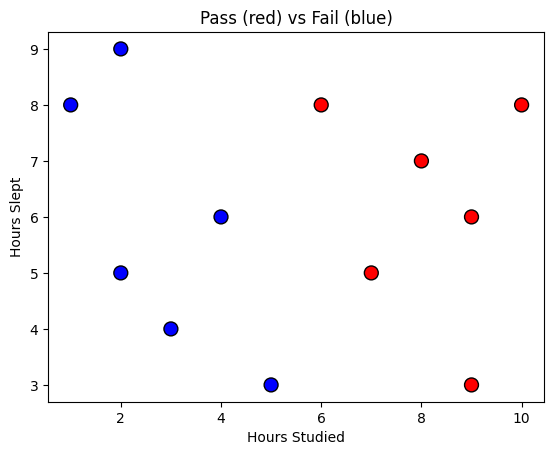

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['hours_studied'], df['hours_slept'], c=df['result'], cmap='bwr', s=100, edgecolor='k')
plt.xlabel('Hours Studied')
plt.ylabel('Hours Slept')
plt.title('Pass (red) vs Fail (blue)')
plt.show()

In [ ]:
#fit_transform() = learn the transformation parameters from this data AND apply them
# transform() = just apply parameters that were already learned earlier — don't learn anything new

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale — CRITICAL for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# "Train" (really just stores the data)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [ ]:
# Try: studied 5.5 hours, slept 7 hours — will they pass?
new_student = [[5.5, 7]]
new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)
neighbors = model.kneighbors(new_student_scaled)  # see which points it looked at

print("Predicted:", "Pass" if prediction[0] == 1 else "Fail")
print("Nearest neighbor distances:", neighbors[0])
print("Nearest neighbor indices:", neighbors[1])

Predicted: Pass
Nearest neighbor distances: [[0.56911289 0.80770293 1.19416696 1.25557429 1.55290642]]
Nearest neighbor indices: [[3 6 8 5 2]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21],
    'weights': ['distance'],   # see below
    'metric': ['euclidean']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)

#the warnings below are due to very samall datasets

Best params: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'distance'}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_sc

In [ ]:
#naive bayes

import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

data = {
    'hours_studied': [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 9, 10],
    'hours_slept':   [8, 5, 9, 4, 6, 3, 8, 5, 7, 6, 3, 8],
    'result':        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

X = df[['hours_studied', 'hours_slept']]
y = df['result']

# Note: Naive Bayes doesn't strictly REQUIRE scaling (unlike KNN),
# since it works with each feature's own distribution independently.
# But it doesn't hurt either.

model = GaussianNB()
model.fit(X, y)

GaussianNB()

In [ ]:
test_points = [[1, 8], [4, 6], [5.5, 7], [6, 2], [9, 9]]

for point in test_points:
    pred = model.predict([point])[0]
    prob = model.predict_proba([point])[0]
    print(f"Studied={point[0]}, Slept={point[1]} → Predicted: {'Pass' if pred==1 else 'Fail'} | P(Pass): {prob[1]:.3f}")

Studied=1, Slept=8 → Predicted: Fail | P(Pass): 0.000
Studied=4, Slept=6 → Predicted: Fail | P(Pass): 0.014
Studied=5.5, Slept=7 → Predicted: Pass | P(Pass): 0.554
Studied=6, Slept=2 → Predicted: Pass | P(Pass): 0.630
Studied=9, Slept=9 → Predicted: Pass | P(Pass): 1.000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:27

In [ ]:
from sklearn.naive_bayes import GaussianNB

# var_smoothing: adds a tiny value to variance calculations to avoid division-by-zero issues
model = GaussianNB(var_smoothing=1e-9)  # default, rarely needs tuning

In [ ]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB(alpha=1.0)  # this one's worth tuning via GridSearchCV

# What is Support Vector Machine (SVM)?

**Support Vector Machine (SVM)** is a supervised machine learning algorithm mainly used for **classification**. It finds the best **decision boundary (hyperplane)** that separates different classes of data.

### Example

Suppose we have two classes:

```text
Class 0 → Red points
Class 1 → Blue points
```

SVM tries to find a boundary that separates them while keeping the **largest possible margin** between the classes.

## Key Concepts

### 1. Hyperplane

The **hyperplane** is the decision boundary that separates different classes.

For a simple 2D dataset, it can be a line:

```text
Class 0  |  Class 1
   ● ●    |    ○ ○
   ● ●    |    ○ ○
----------|----------
       Decision
        Boundary
```

### 2. Margin

The **margin** is the distance between the decision boundary and the closest data points from each class.

SVM tries to **maximize this margin**.

### 3. Support Vectors

**Support vectors** are the data points closest to the decision boundary. They are the most important points because they determine the position of the boundary.

## Kernel Trick

Sometimes the data cannot be separated using a straight line. SVM can use **kernels** to create a more flexible decision boundary.

Common kernels include:

| Kernel         | Description                                        |
| -------------- | -------------------------------------------------- |
| **Linear**     | Used when data is approximately linearly separable |
| **Polynomial** | Creates polynomial decision boundaries             |
| **RBF**        | Useful for complex, non-linear data                |
| **Sigmoid**    | Uses a sigmoid-based transformation                |

## Important Parameters

| Parameter  | Purpose                                                                 |
| ---------- | ----------------------------------------------------------------------- |
| **C**      | Controls the trade-off between a wider margin and classification errors |
| **kernel** | Determines the type of decision boundary                                |
| **gamma**  | Controls how much influence each data point has for kernels such as RBF |

## Key Points

* SVM is a **supervised learning algorithm**.
* Mainly used for **classification**, but can also be used for regression.
* It finds an optimal **decision boundary**.
* It tries to **maximize the margin**.
* The closest points are called **support vectors**.
* Kernels allow SVM to handle **non-linear data**.


In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

data = {
    'hours_studied': [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 9, 10],
    'hours_slept':   [8, 5, 9, 4, 6, 3, 8, 5, 7, 6, 3, 8],
    'result':        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

X = df[['hours_studied', 'hours_slept']]
y = df['result']

# SVM is very sensitive to feature scale — always scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train with RBF kernel
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_scaled, y)

SVC()

In [ ]:
test_points = [[1, 8], [4, 6], [5.5, 7], [6, 2], [9, 9]]

for point in test_points:
    scaled_point = scaler.transform([point])
    pred = model.predict(scaled_point)[0]
    print(f"Studied={point[0]}, Slept={point[1]} → Predicted: {'Pass' if pred==1 else 'Fail'}")

Studied=1, Slept=8 → Predicted: Fail
Studied=4, Slept=6 → Predicted: Fail
Studied=5.5, Slept=7 → Predicted: Pass
Studied=6, Slept=2 → Predicted: Fail
Studied=9, Slept=9 → Predicted: Pass


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
model.fit(X_scaled, y)

prob = model.predict_proba(scaled_point)  # now works, but slower to train

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


### Why SVM Is a Strong Choice for Projects

- Performs very well on **high-dimensional data**, such as text classification, gene expression data, and image features.
- The **kernel trick** allows SVM to handle complex, non-linear data without requiring deep learning.
- Can be **resistant to overfitting** in high-dimensional spaces when parameters like `C` and `gamma` are properly tuned.
- SVM was historically considered one of the **powerful classical machine learning models** before ensemble methods such as Random Forest and XGBoost became more popular.
- It is still a **well-respected algorithm** and is commonly discussed in machine learning interviews.



## Decision Trees

### Core Idea
Recursively ask yes/no questions about features, splitting the data at each step, until reaching a final prediction (leaf).

```
                  Hours Studied ≥ 6?
                 /                  \
              No                     Yes
              |                       |
        Hours Slept ≥ 5?          Predict: Pass
           /         \
         No           Yes
         |              |
   Predict: Fail   Predict: Pass
```

### Splitting Criteria — Impurity Measures

**Gini Impurity**
$$Gini = 1-\sum_{i=1}^n p_i^2$$
0 = pure, 0.5 = maximally mixed (binary case).

**Entropy / Information Gain**
$$Entropy = -\sum_{i=1}^n p_i\log_2(p_i)$$
0 = pure, 1 = maximally mixed (binary case). Information Gain = entropy reduction from a split.

Gini vs Entropy: usually give similar trees; Gini is faster (no log), sklearn's default.

### The Algorithm
```
1. Start with all data at root
2. Try every (feature, split point) combination
3. Pick the split with the largest impurity reduction
4. Split data into two branches
5. Repeat recursively
6. Stop when pure, or a stopping condition is hit
```

### Overfitting & Stopping Conditions
Unchecked trees split until every leaf has 1 sample — pure memorization.

| Hyperparameter | Controls |
|---|---|
| `max_depth` | Max question-levels; smaller = simpler, less overfitting |
| `min_samples_split` | Min samples needed before a node can split |
| `min_samples_leaf` | Min samples required at a leaf |
| `max_features` | Features considered per split (mainly relevant for Random Forest) |
| `criterion` | `'gini'` or `'entropy'` |

Same bias-variance tradeoff pattern as K (KNN) and C/gamma (SVM): unrestricted tree = low bias/high variance (overfits); heavily restricted = high bias/low variance (underfits).

### Code
```python
from sklearn.tree import DecisionTreeClassifier

# No scaling needed — trees split on raw thresholds
model = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

### Visualizing the Tree
```python
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=X.columns, class_names=['Fail','Pass'], filled=True, rounded=True)
plt.show()
```

### Feature Importance
```python
importances = model.feature_importances_
for feature, importance in zip(X.columns, importances):
    print(f"{feature}: {importance:.3f}")
```
Built-in feature-selection signal, similar in spirit to Lasso for linear models.

### Hyperparameter Tuning
```python
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
```

### Big Weakness — Instability
High variance: a small change in training data can produce a completely different tree (especially the first/most important split). This instability is the core motivation for **Random Forest** — train many trees on random data variations and average their votes.

### Summary
| Aspect | Value |
|---|---|
| Core idea | Recursive splitting to maximize purity |
| Impurity measures | Gini (default) or Entropy |
| Key hyperparameters | `max_depth`, `min_samples_split`, `min_samples_leaf` |
| Needs scaling? | No |
| Biggest strength | Fully interpretable, visualizable |
| Biggest weakness | High variance, unstable, easily overfits |
| Leads to | Random Forest (ensemble of trees) |

---

## 6. Cross-Algorithm Comparison

| | Logistic Regression | KNN | Naive Bayes | SVM | Decision Tree |
|---|---|---|---|---|---|
| Decision boundary | Linear | Any shape (local) | Probabilistic regions | Linear/non-linear (kernel) | Axis-aligned splits |
| Needs scaling? | Somewhat | Critical | No | Critical | No |
| Interpretability | High (coefficients) | Low | Medium | Low | Very high |
| Handles non-linear data | No | Yes | Somewhat | Yes (with kernel) | Yes, naturally |
| Overfitting risk | Moderate (controlled by `C`) | Low K = overfits | Rarely | Moderate (`C`/`gamma`) | High if unrestricted |
| Training speed | Moderate | Instant (lazy) | Very fast | Slower on large data | Fast |
| Prediction speed | Fast | Slow on large data | Very fast | Fast (support vectors only) | Fast |
| Outputs probability | Yes | Yes | Yes | No (needs `probability=True`) | Yes (leaf proportions) |

---

## 7. General Rules Recap

- **`fit_transform()`** on training data (learns + applies parameters), **`transform()`** only on test data (applies already-learned parameters) — prevents **data leakage**. Applies to scalers, imputers, encoders — any preprocessing that "learns" from data.
- **`stratify=y`** in `train_test_split` keeps class proportions consistent across train/test — important for imbalanced classes.
- Hyperparameter tuning pattern is always the same: define `param_grid` → `GridSearchCV`/`RandomizedSearchCV` → `cv` folds → pick best by a classification `scoring` metric (F1, accuracy, recall) → never tune using the test set.

---

## 8. Suggested Study Order From Here

```
1. ✅ Classification basics (Logistic Regression, KNN, Naive Bayes, SVM, Decision Trees)
2. → Ensemble methods (Random Forest, Gradient Boosting / XGBoost) — heavily asked in interviews
3. → Unsupervised learning (K-Means, Hierarchical Clustering, PCA)
4. → Bias-variance tradeoff + model evaluation strategy (ties everything together)
5. → Build one combined portfolio project (regression + classification + unsupervised on one dataset)
```

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

data = {
    'hours_studied': [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 9, 10],
    'hours_slept':   [8, 5, 9, 4, 6, 3, 8, 5, 7, 6, 3, 8],
    'result':        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

X = df[['hours_studied', 'hours_slept']]
y = df['result']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# No scaling needed — Decision Trees split on raw thresholds, not distance
model = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
model.fit(X_train,y_train )

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score,classification_report

y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [ ]:
test_points = [[1, 8], [4, 6], [5.5, 7], [6, 2], [9, 9]]

for point in test_points:
    pred = model.predict([point])[0]
    print(f"Studied={point[0]}, Slept={point[1]} → Predicted: {'Pass' if pred==1 else 'Fail'}")

Studied=1, Slept=8 → Predicted: Fail
Studied=4, Slept=6 → Predicted: Fail
Studied=5.5, Slept=7 → Predicted: Fail
Studied=6, Slept=2 → Predicted: Pass
Studied=9, Slept=9 → Predicted: Pass


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


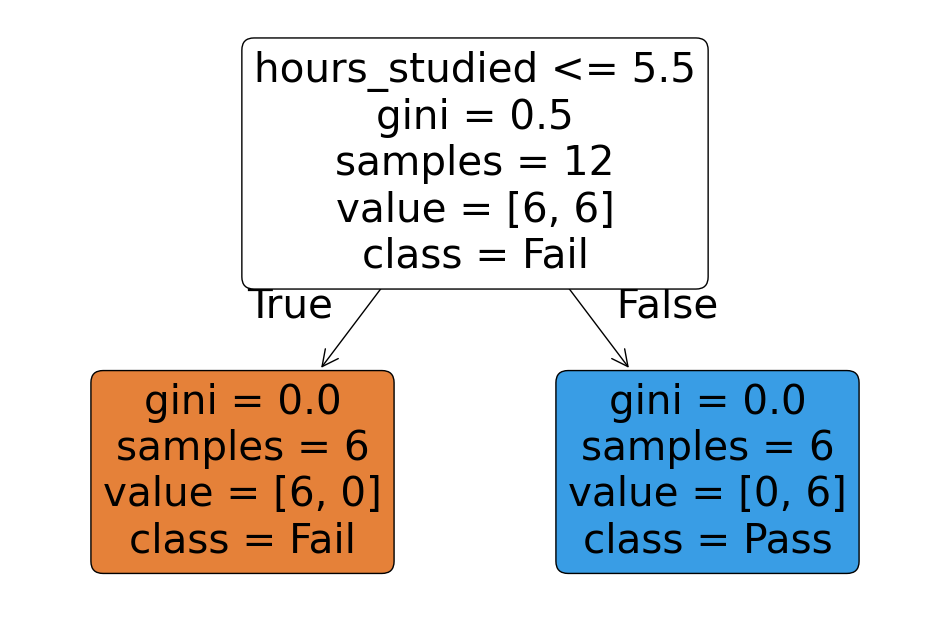

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=['hours_studied', 'hours_slept'],
          class_names=['Fail', 'Pass'], filled=True, rounded=True)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best params: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
# Check train accuracy vs test accuracy
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 1.0


# Random Forest

---

## Core Idea

Instead of trusting **one** Decision Tree, train **many** Decision Trees on slightly different versions of the data, then combine their predictions.

```
Tree 1 → Predict: Pass
Tree 2 → Predict: Fail
Tree 3 → Predict: Pass
Tree 4 → Predict: Pass
Tree 5 → Predict: Pass
                              → Majority Vote → Predict: Pass
```

This is an **ensemble method** — combining multiple weaker/individually-unstable models into one stronger, more stable model. Random Forest is specifically a **Bagging** (Bootstrap Aggregating) ensemble.

Directly solves the "Big Weakness" of a single Decision Tree: high variance and instability.

---

## Why Averaging Many Trees Helps

A single Decision Tree is like asking one person's opinion — it can be biased or overly influenced by a few unusual data points. Averaging many trees (each trained slightly differently) is like asking a large diverse committee — individual mistakes cancel out, and the majority converges toward the right answer.

Mathematically: averaging reduces **variance** without increasing bias much. Since Decision Trees mainly suffer from high variance, this is exactly the right fix.

---

## How Random Forest Builds "Different" Trees — Two Sources of Randomness

### 1. Bootstrap Sampling (Bagging) — Random Rows
Each tree is trained on a **random sample of the training data, drawn with replacement** (same size as original dataset, but some rows repeated, some left out).

```
Original data: [1, 2, 3, 4, 5]
Tree 1's sample: [1, 1, 3, 4, 5]   (2 repeated, some left out)
Tree 2's sample: [2, 2, 3, 3, 5]
Tree 3's sample: [1, 4, 4, 5, 5]
```

Each tree sees a slightly different "view" of the data.

### 2. Random Feature Selection — Random Columns
At **each split**, instead of considering *all* features, Random Forest only considers a **random subset** of features.

**Example:** With 10 features, each split might only look at a random 3 of them, deciding the best split among just those 3.

This is the crucial second ingredient — without it, if one feature is very strong, *every* tree would just pick that same feature for its first split, making all trees very similar (correlated), which defeats the purpose of averaging. Random feature selection forces trees to be genuinely different from each other.

---

## Making the Final Prediction

- **Classification** → majority vote across all trees
- **Regression** → average of all trees' predicted values

---

## Key Hyperparameters

| Hyperparameter | What it controls |
|---|---|
| `n_estimators` | Number of trees in the forest. More trees = more stable, but diminishing returns + slower |
| `max_depth` | Max depth of each individual tree (same concept as Decision Tree) |
| `max_features` | How many features to randomly consider at each split (`'sqrt'` common default for classification) |
| `min_samples_split` | Min samples needed to split a node |
| `min_samples_leaf` | Min samples required at a leaf |
| `bootstrap` | Whether to use bootstrap sampling (True by default) |

`n_estimators` is the truly new hyperparameter here — more trees generally means better, more stable predictions, but with diminishing returns past a certain point (say, 100–300), while training time keeps growing linearly.

⚠️ Random Forest hyperparameter grids get expensive quickly (many hyperparameters × many values) — `RandomizedSearchCV` is often preferred over `GridSearchCV` here.

---

## Feature Importance — More Reliable Than a Single Tree

Since importance is averaged across all trees (not just one tree's potentially noisy split choices), Random Forest's feature importance scores are considered **much more trustworthy** than a single Decision Tree's.

---

## Out-of-Bag (OOB) Score — Free Built-in Validation

Since each tree only sees a bootstrap sample (~63% of the data, statistically, due to sampling with replacement), the remaining ~37% of data (the "out-of-bag" samples) were **never seen by that particular tree**. Random Forest can use these leftover samples as a free internal validation check, without touching the actual test set.

This is a genuinely unique feature of bagging-based ensembles — no other algorithm studied so far gives a free validation estimate built directly into training.

---

## Random Forest vs a Single Decision Tree

| | Decision Tree | Random Forest |
|---|---|---|
| Number of models | 1 | Many (e.g. 100) |
| Overfitting risk | High, if unrestricted | Much lower — averaging smooths it out |
| Variance | High | Low (this is the whole point) |
| Interpretability | Very high — can visualize the whole tree | Lower — can't visualize 100 trees, but feature importance still works |
| Training speed | Fast | Slower (training many trees) |
| Prediction speed | Very fast | Slower (must query every tree, then vote) |
| Accuracy (typical) | Decent | Usually noticeably better |

---

## Why It's Popular in Practice / Interviews

- One of the most reliable **"just works" baseline models** for tabular data — often near state-of-the-art without much tuning
- Handles both classification and regression (same averaging idea, but averaging numeric predictions instead of voting, for regression)
- Naturally resistant to overfitting compared to single trees
- Doesn't need feature scaling
- Gives useful feature importance out of the box
- The classic "second model to try after Logistic Regression" in most real-world ML workflows

---

## Summary

| Aspect | Value |
|---|---|
| Type | Ensemble (Bagging) of Decision Trees |
| Core idea | Many trees on random data + random features, then vote/average |
| Randomness sources | Bootstrap sampling (rows) + random feature subsets (columns) |
| Key hyperparameter | `n_estimators` (number of trees) |
| Needs scaling? | No |
| Overfitting risk | Much lower than a single tree |
| Bonus feature | OOB score — free validation without a separate holdout |
| Best for | Strong general-purpose baseline for tabular data |

---

## Ensemble Strategy Note — Bagging vs Boosting

Random Forest uses **Bagging** — many trees trained independently and in parallel, then averaged/voted.

The other major ensemble strategy is **Boosting** (used by Gradient Boosting / XGBoost) — trees built **sequentially**, each new tree specifically correcting the previous tree's mistakes. A genuinely different mechanism from Bagging, and the natural next topic after Random Forest.

---



In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

data = {
    'hours_studied': [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 9, 10],
    'hours_slept':   [8, 5, 9, 4, 6, 3, 8, 5, 7, 6, 3, 8],
    'result':        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

X = df[['hours_studied', 'hours_slept']]
y = df['result']
# Split first, always
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# No scaling needed — same as Decision Tree, splits are threshold-based
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Test Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [2]:
test_points = [[1, 8], [4, 6], [5.5, 7], [6, 2], [9, 9]]

for point in test_points:
    pred = model.predict([point])[0]
    prob = model.predict_proba([point])[0]
    print(f"Studied={point[0]}, Slept={point[1]} → Predicted: {'Pass' if pred==1 else 'Fail'} | P(Pass): {prob[1]:.3f}")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

Studied=1, Slept=8 → Predicted: Fail | P(Pass): 0.120
Studied=4, Slept=6 → Predicted: Fail | P(Pass): 0.270
Studied=5.5, Slept=7 → Predicted: Pass | P(Pass): 0.670
Studied=6, Slept=2 → Predicted: Fail | P(Pass): 0.470
Studied=9, Slept=9 → Predicted: Pass | P(Pass): 0.800


In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 50}


# Gradient Boosting & XGBoost

---

## Bagging vs Boosting — The Fundamental Difference

**Random Forest (Bagging):** Trees trained **independently and in parallel**. Each tree doesn't know or care what the others are doing. Final answer = vote/average.

**Boosting:** Trees trained **sequentially**. Each new tree is built specifically to **fix the mistakes** of the trees before it. Final answer = weighted sum of all trees' contributions.

```
Bagging (Random Forest):
Tree 1 (independent) ─┐
Tree 2 (independent) ─┼─→ Average/Vote
Tree 3 (independent) ─┘

Boosting (Gradient Boosting):
Tree 1 → makes errors → Tree 2 fixes Tree 1's errors → makes remaining errors → Tree 3 fixes those → ...
```

Bagging reduces **variance** by averaging independent guesses. Boosting reduces **bias** by iteratively focusing on what's still being gotten wrong.

---

## Core Idea of Gradient Boosting

1. Start with a very simple/weak model (often just predicting the average, or a shallow single-split tree)
2. Calculate the **errors (residuals)** — how wrong current predictions are
3. Train a **new small tree specifically to predict those errors**
4. Add this new tree's predictions (scaled down) to the running total
5. Repeat: recalculate errors on the updated predictions, train another tree to fix *those* errors
6. Continue for many rounds — each tree is a small correction on top of everything before it

**Key idea: each tree predicts the residual error of the combined model so far, not the original target directly.**

---

## Worked Example (Regression) — Predicting House Price = 300

```
Step 0: Initial guess (average) = 250
        Residual = 300 - 250 = 50

Step 1: Tree 1 predicts residual → +30
        Combined prediction = 250 + 30 = 280
        Remaining residual = 300 - 280 = 20

Step 2: Tree 2 predicts THIS residual → +15
        Combined prediction = 280 + 15 = 295
        Remaining residual = 300 - 295 = 5

Step 3: Tree 3 predicts THIS residual → +4
        Combined prediction = 295 + 4 = 299
        Remaining residual = 300 - 299 = 1
        ...and so on
```

Each tree chips away more of the remaining error. This is literally gradient descent — but instead of adjusting weights (like Logistic Regression/SGD), it adjusts predictions by adding new trees, moving in the direction that reduces the loss fastest — hence "Gradient" Boosting.

---

## Why Small, Scaled-Down Steps — The Learning Rate

Each new tree's contribution is scaled down by a **learning rate** before being added:

$$\text{Combined Prediction} = \text{Initial guess} + \eta \times \text{Tree}_1 + \eta \times \text{Tree}_2 + \dots$$

Where $\eta$ (learning rate, typically 0.01–0.3) controls how much each tree influences the final answer.

| Learning rate | Effect |
|---|---|
| Small | Each tree contributes a little, needs more trees to converge, tends to generalize better |
| Large | Each tree contributes a lot, converges in fewer trees, risks overshooting/overfitting |

Same learning-rate tradeoff concept as SGD — applied here to how much each *tree* is trusted, instead of each gradient step.

---

## Classification Version

Same core idea, but works with residuals of the **log-odds** (same concept as Logistic Regression), then converts to probability via sigmoid/softmax at the end. "Each tree corrects the previous combined model's errors" stays identical.

---

## What is XGBoost?

Not a different algorithm — a highly optimized, industrial-strength **implementation** of gradient boosting with genuine improvements:

| Improvement | What it does |
|---|---|
| Regularization built-in | L1/L2 penalties directly in the tree-building objective — reduces overfitting more than plain Gradient Boosting |
| Handles missing values automatically | Learns best direction to send missing values during splits, no manual imputation needed |
| Parallelized tree construction | Faster training (within-tree split-finding is parallelized, even though boosting is sequential across trees) |
| Built-in cross-validation | `xgb.cv()` for tuning `n_estimators` efficiently |
| Tree pruning | "max_depth first, then prune back" instead of greedy stop-early splitting — tends to find better trees |

This is why XGBoost dominated Kaggle competitions and real-world tabular ML for years — same core boosting idea, engineered to be faster, more accurate, more robust to overfitting.

**Sibling libraries:** LightGBM and CatBoost — similar ideas with further optimizations (histogram-based splitting, native categorical feature handling). XGBoost is the classic one to learn first.

---

## Key Hyperparameters

| Hyperparameter | What it controls |
|---|---|
| `n_estimators` | Number of boosting rounds (trees). More = more correction opportunities, but risk of overfitting if too many |
| `learning_rate` (`eta` in XGBoost) | How much each tree contributes. Smaller = needs more trees, generally better generalization |
| `max_depth` | Depth of each individual tree. Kept **shallow** (3–6) — unlike Random Forest, which can afford deeper trees |
| `subsample` | Fraction of rows randomly sampled per tree (adds bagging-style randomness into boosting) |
| `colsample_bytree` | Fraction of features randomly sampled per tree (same idea as Random Forest's `max_features`) |
| `reg_alpha` / `reg_lambda` | L1/L2 regularization strength (XGBoost-specific) |

**Important nuance:** `n_estimators` and `learning_rate` are tightly linked — small learning rate needs more estimators for the same performance, large learning rate needs fewer. Tune together, not independently.

---

## Why Boosting Trees Are Kept Shallow (Contrast With Random Forest)

Random Forest trees are often deep and individually overfit — fine because averaging many overfit-but-independent trees cancels out the noise.

Boosting trees are deliberately kept **shallow and weak** on their own ("weak learners") — because boosting *sequentially* combines them; letting them get deep and strong would cause the whole ensemble to overfit fast, since each subsequent tree would aggressively chase noise in the residuals.

**Random Forest = many strong, independent, deep trees averaged. Boosting = many weak, shallow, sequential trees added together.**

---

## Overfitting Risk — Boosting's Real Weakness

Since each tree explicitly corrects the errors of everything before it, boosting can start **fitting noise** in later rounds if allowed to run too long — a real, well-known failure mode, unlike Random Forest which is naturally more resistant to overfitting by design.

**Early stopping** is the standard fix — stop adding trees once validation performance stops improving:
```
Track validation loss after each new tree is added.
If validation loss hasn't improved in N rounds → stop training early.
```
Prevents the model from continuing to chase residual noise past the point of diminishing (or negative) returns.

---

## Boosting vs Bagging (Random Forest) — Full Comparison

| | Random Forest (Bagging) | Gradient Boosting / XGBoost |
|---|---|---|
| Tree training | Parallel, independent | Sequential, each fixes previous errors |
| Reduces | Variance | Bias (mainly), some variance too |
| Individual tree depth | Often deep | Kept shallow (weak learners) |
| Overfitting risk | Lower, naturally resistant | Higher, needs careful tuning/early stopping |
| Speed to train | Faster (parallelizable across trees) | Slower (inherently sequential across trees) |
| Typical accuracy on tabular data | Very good | Often the best — especially XGBoost/LightGBM |
| Key hyperparameter | `n_estimators` (more is safer) | `n_estimators` + `learning_rate` (must balance carefully) |
| Needs scaling? | No | No |

---

## Why This Is So Interview-Relevant

Gradient Boosting/XGBoost is one of the most commonly asked-about algorithms in ML interviews — the most consistently winning approach for structured/tabular data (vs. deep learning, which dominates unstructured data like images/text/audio). Explaining the bagging-vs-boosting distinction clearly, and why boosting trees are shallow while bagging trees are deep, is a common way interviewers check real understanding vs surface-level tool usage.

---



## Summary

| Aspect | Value |
|---|---|
| Type | Ensemble (Boosting) — sequential trees |
| Core idea | Each new tree corrects the residual errors of the combined model so far |
| Analogy to gradient descent | Trees ≈ steps toward minimizing loss, scaled by learning rate |
| Individual tree depth | Shallow (weak learners), unlike Random Forest |
| Key hyperparameters | `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree` |
| Needs scaling? | No |
| Biggest risk | Overfitting if run too long — use early stopping |
| XGBoost's edge | Built-in regularization, missing value handling, speed, pruning |
| Best for | Tabular/structured data — often the strongest classical ML option available |

---




In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

data = {
    'hours_studied': [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 9, 10],
    'hours_slept':   [8, 5, 9, 4, 6, 3, 8, 5, 7, 6, 3, 8],
    'result':        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

X = df[['hours_studied', 'hours_slept']]
y = df['result']

# Split first, always
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# No scaling needed — tree-based, same as Decision Tree/Random Forest
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [5]:
test_points = [[1, 8], [4, 6], [5.5, 7], [6, 2], [9, 9]]

for point in test_points:
    pred = model.predict([point])[0]
    prob = model.predict_proba([point])[0]
    print(f"Studied={point[0]}, Slept={point[1]} → Predicted: {'Pass' if pred==1 else 'Fail'} | P(Pass): {prob[1]:.3f}")

Studied=1, Slept=8 → Predicted: Fail | P(Pass): 0.000
Studied=4, Slept=6 → Predicted: Fail | P(Pass): 0.000
Studied=5.5, Slept=7 → Predicted: Fail | P(Pass): 0.000
Studied=6, Slept=2 → Predicted: Pass | P(Pass): 1.000
Studied=9, Slept=9 → Predicted: Pass | P(Pass): 1.000


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warni

In [6]:
!pip install xgboost

In [7]:

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.3333333333333333
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
model = XGBClassifier(
    n_estimators=500,       # set high, let early stopping decide the actual number used
    learning_rate=0.1,
    max_depth=3,
    early_stopping_rounds=10,
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],   # validation set to monitor
    verbose=False
)

print("Best number of trees used:", model.best_iteration)

Best number of trees used: 0


In [9]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(2, 8),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

random_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=param_dist,
    n_iter=30, cv=5, scoring='f1', random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train)
print("Best params:", random_search.best_params_)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best params: {'colsample_bytree': np.float64(0.6624074561769746), 'learning_rate': np.float64(0.05679835610086079), 'max_depth': 4, 'n_estimators': 252, 'subsample': np.float64(0.9464704583099741)}
